In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier



In [22]:
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [23]:
df=pd.get_dummies(df)
df.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label',
       'gender_female', 'gender_male', 'platform_usage_Both',
       'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_high', 'social_interaction_level_low',
       'social_interaction_level_medium'],
      dtype='str')

In [24]:
# Dataset Description
# •	Input dataset: Teen_Mental_Health_Dataset.csv
#  Target Variable
# •	depression_label
# o	(0 = No Depression, 1 = Depression)
# Preprocessing
# •	Convert categorical variables (e.g., gender, platform_usage) using one-hot encoding
# •	Handle missing values if present
# •	Feature scaling (recommended for KNN & SVM)
# Experimental Setup
# •	Dataset split into training and testing sets using different test sizes:
# 0.05, 0.10, 0.15, 0.20, 0.25
# •	random_state = 42 for reproducibility
# Machine Learning Models Used
# 1. K-Nearest Neighbors (KNN)
# •	Model: KNeighborsClassifier
# •	Parameters:
# o	n_neighbors = 29
# 2. Decision Tree Classifier
# •	Model: DecisionTreeClassifier
# o	Parameters:,criterion = 'entropy',max_depth = 4,random_state = 42
# 3. Random Forest Classifier
# •	Model: RandomForestClassifier
# o	Parameters: n_estimators = 100,max_depth = 4,andom_state = 42
# 4. Support Vector Machine (SVM)
# •	Model: SVC
# o	Parameters: C = 10, kernel = 'rbf', random_state = 42
# Visualization
# •	A line graph is plotted using Plotly Express
# Graph Details:
# •	X-axis: Test Size
# •	Y-axis: Accuracy
# •	Comparison Models:
# o	KNN
# o	Decision Tree
# o	Random Forest
# o	SVM


In [ ]:
x=df.drop("depression_label",axis=1)
y=df["depression_label"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
model=KNeighborsClassifier(n_neighbors=29)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
accuracy_of_knn=accuracy_score(y_test, y_pred)


Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       292
           1       0.00      0.00      0.00         8

    accuracy                           0.97       300
   macro avg       0.49      0.50      0.49       300
weighted avg       0.95      0.97      0.96       300

Confusion Matrix:
 [[292   0]
 [  8   0]]
Accuracy Score: 0.9733333333333334


c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
model=DecisionTreeClassifier(criterion = 'entropy',max_depth = 4,random_state = 42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
accuracy_of_decision_tree=accuracy_score(y_test, y_pred)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       292
           1       1.00      0.88      0.93         8

    accuracy                           1.00       300
   macro avg       1.00      0.94      0.97       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
 [[292   0]
 [  1   7]]
Accuracy Score: 0.9966666666666667


In [28]:
model=RandomForestClassifier(n_estimators = 100,max_depth = 4,random_state = 42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
accuracy_score_of_random_forest=accuracy_score(y_test, y_pred)

c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       292
           1       0.00      0.00      0.00         8

    accuracy                           0.97       300
   macro avg       0.49      0.50      0.49       300
weighted avg       0.95      0.97      0.96       300

Confusion Matrix:
 [[292   0]
 [  8   0]]
Accuracy Score: 0.9733333333333334


In [29]:
model=SVC(C=10, kernel='rbf', random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
accuracy_score_of_svm=accuracy_score(y_test, y_pred)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       292
           1       1.00      0.38      0.55         8

    accuracy                           0.98       300
   macro avg       0.99      0.69      0.77       300
weighted avg       0.98      0.98      0.98       300

Confusion Matrix:
 [[292   0]
 [  5   3]]
Accuracy Score: 0.9833333333333333


In [30]:
print("Accuracy of KNN:", accuracy_of_knn)
print("Accuracy of Decision Tree:", accuracy_of_decision_tree)
print("Accuracy of Random Forest:", accuracy_score_of_random_forest)
print("Accuracy of SVM:", accuracy_score_of_svm)

Accuracy of KNN: 0.9733333333333334
Accuracy of Decision Tree: 0.9966666666666667
Accuracy of Random Forest: 0.9733333333333334
Accuracy of SVM: 0.9833333333333333


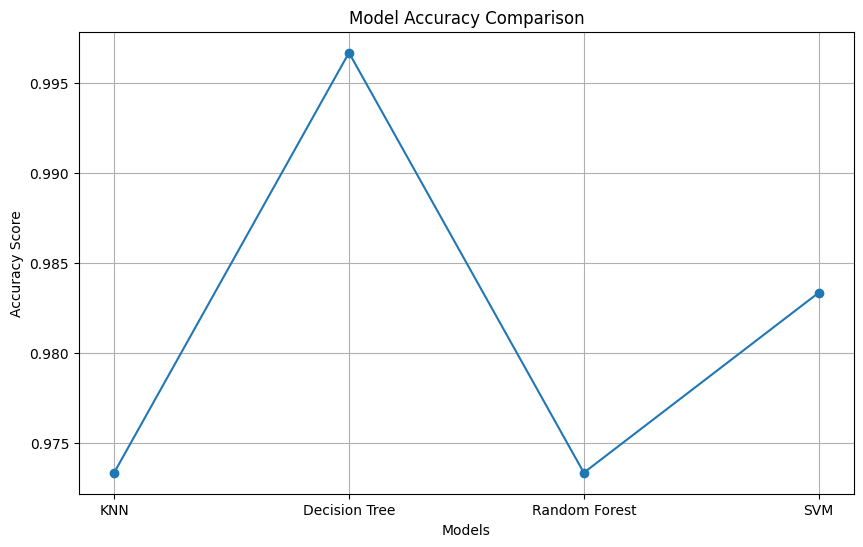

In [33]:
plt.figure(figsize=(10, 6))
models = ['KNN', 'Decision Tree', 'Random Forest', 'SVM']
accuracy_scores = [accuracy_of_knn, accuracy_of_decision_tree, accuracy_score_of_random_forest, accuracy_score_of_svm]
plt.plot(models, accuracy_scores, marker='o')
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.grid()
plt.show()

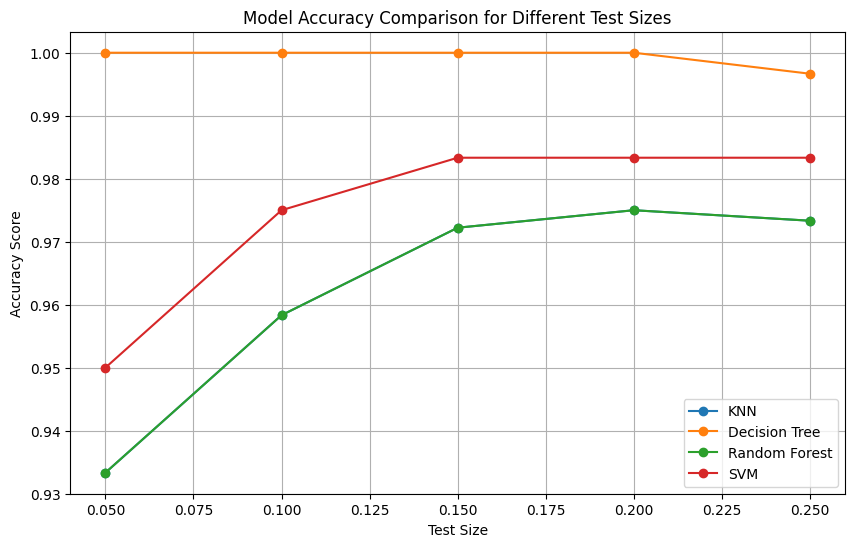

In [ ]:
x=df.drop("depression_label",axis=1)
y=df["depression_label"]
test_sizes=[0.05, 0.10, 0.15, 0.20, 0.25]
accuracy_of_models_for_test_sizes={}
modelKNN=KNeighborsClassifier(n_neighbors=29)
modelDecisionTree=DecisionTreeClassifier(criterion = 'entropy',max_depth = 4,random_state = 42)
modelRandomForest=RandomForestClassifier(n_estimators = 100,max_depth = 4,random_state = 42)
modelSVM=SVC(C=10, kernel='rbf', random_state=42)
for test_size in test_sizes:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=test_size,random_state=42)
    modelKNN.fit(x_train,y_train)
    y_pred=modelKNN.predict(x_test)
    accuracy_of_models_for_test_sizes[test_size]={"KNN": accuracy_score(y_test, y_pred)}
    modelDecisionTree.fit(x_train,y_train)
    y_pred=modelDecisionTree.predict(x_test)
    accuracy_of_models_for_test_sizes[test_size]["Decision Tree"] = accuracy_score(y_test, y_pred)
    modelRandomForest.fit(x_train,y_train)
    y_pred=modelRandomForest.predict(x_test)
    accuracy_of_models_for_test_sizes[test_size]["Random Forest"] = accuracy_score(y_test, y_pred)
    modelSVM.fit(x_train,y_train)
    y_pred=modelSVM.predict(x_test)
    accuracy_of_models_for_test_sizes[test_size]["SVM"] = accuracy_score(y_test, y_pred)
plt.figure(figsize=(10, 6))
for model in ['KNN', 'Decision Tree', 'Random Forest', 'SVM']:
    accuracy_scores = [accuracy_of_models_for_test_sizes[test_size][model] for test_size in test_sizes]
    plt.plot(test_sizes, accuracy_scores, marker='o', label=model)
plt.title('Model Accuracy Comparison for Different Test Sizes')
plt.xlabel('Test Size')
plt.ylabel('Accuracy Score')
plt.grid()
plt.legend()
plt.show()


In [ ]:
# Now Plot graph using plotly express
accuracy_df = pd.DataFrame(accuracy_of_models_for_test_sizes).T
accuracy_df.reset_index(inplace=True)
accuracy_df.rename(columns={'index': 'Test Size'}, inplace=True)
fig = px.line(accuracy_df, x='Test Size', y=['KNN', 'Decision Tree', 'Random Forest', 'SVM'], markers=True, title='Model Accuracy Comparison for Different Test Sizes')
fig.update_layout(xaxis_title='Test Size', yaxis_title='Accuracy Score')
fig.show()

In [ ]:
# # Now Find the max accuracy of every model in diffrent cases
# # For KNN
# x=df.drop("depression_label",axis=1)
# y=df["depression_label"]
# test_size=[0.05,0.1,0.15,0.2,0.25]
# for i in test_size:
#     x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
#     best_accuracy_according_to_test_sizes={}
#     best_accuracy=0
#     for j in range(1,50):
#         model=KNeighborsClassifier(n_neighbors=j)
#         model.fit(x_train,y_train)
#         y_pred=model.predict(y_test)
#         current_accurancy=
#         if best_accuracy<accuracy_score(y_pred):
#             best_accuracy=

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error
x=df.drop("depression_label",axis=1)
x=pd.get_dummies(x)
y=df["depression_label"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
degrees=[1,2,3,4,5]
r2_scores=[]
r2_max=0
best_degree=0
for i in degrees:
    poly_features = PolynomialFeatures(degree=i)
    x_poly_train = poly_features.fit_transform(x_train)
    x_poly_test = poly_features.transform(x_test)
    model=LinearRegression()
    model.fit(x_poly_train,y_train)
    y_pred=model.predict(x_poly_test)
    r2_score_of_model=r2_score(y_test, y_pred)
    r2_scores.append(r2_score_of_model)
    if r2_score_of_model>r2_max:
        r2_max=r2_score_of_model
        best_degree=i
print("Best Degree:", best_degree)
print("R2 Scores for each degree:", r2_scores)
print("Max R2 Score:", r2_max)


Best Degree: 2
R2 Scores for each degree: [0.07258978563632346, 0.16947687279411272, -0.22195855401233522, -3.170258687445644, -2.0034911036004734]
Max R2 Score: 0.16947687279411272


In [42]:
test_sizes=[0.05, 0.10, 0.15, 0.20, 0.25]
for i in test_sizes:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    linear_model=LinearRegression()
    linear_model.fit(x_train,y_train)
    y_pred=linear_model.predict(x_test)
    r2_score_of_linear_regression=r2_score(y_test, y_pred)
    absolute_error=mean_squared_error(y_test, y_pred)
    poly_features = PolynomialFeatures(degree=best_degree)
    x_poly_train = poly_features.fit_transform(x_train)
    x_poly_test = poly_features.transform(x_test)
    poly_model=LinearRegression()
    poly_model.fit(x_poly_train,y_train)
    y_poly_pred=poly_model.predict(x_poly_test)
    r2_score_of_polynomial_regression=r2_score(y_test, y_poly_pred)
    absolute_error_of_polynomial_regression=mean_squared_error(y_test, y_poly_pred)

print("R2 Score of Linear Regression for different test sizes:", r2_score_of_linear_regression)
print("Absolute Error of Linear Regression for different test sizes:", absolute_error)
print("R2 Score of Polynomial Regression for different test sizes:", r2_score_of_polynomial_regression)
print("Absolute Error of Polynomial Regression for different test sizes:", absolute_error_of_polynomial_regression)



R2 Score of Linear Regression for different test sizes: 0.09591163726403495
Absolute Error of Linear Regression for different test sizes: 0.023466115726124608
R2 Score of Polynomial Regression for different test sizes: 0.23028020914960545
Absolute Error of Polynomial Regression for different test sizes: 0.019978504793628022


In [ ]:
accuracy_df = pd.DataFrame({
    'Test Size': test_sizes,
    'R2 Score Linear Regression': r2_score_of_linear_regression,
    'R2 Score Polynomial Regression': r2_score_of_polynomial_regression,
    'MSE Linear Regression': absolute_error,
    'MSE Polynomial Regression': absolute_error_of_polynomial_regression
})
fig = px.line(accuracy_df, x='Test Size', y=['R2 Score Linear Regression', 'R2 Score Polynomial Regression'], markers=True, title='Test Size vs R² Score')
fig.update_layout(xaxis_title='Test Size', yaxis_title='R² Score')
fig.show()
fig = px.line(accuracy_df, x='Test Size', y=['MSE Linear Regression', 'MSE Polynomial Regression'], markers=True, title='Test Size vs MSE')
fig.update_layout(xaxis_title='Test Size', yaxis_title='MSE')
fig.show()
